In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração estética dos gráficos para a apresentação
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Modelos e Métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from mlxtend.frequent_patterns import apriori, association_rules

# Carregamento dos dados
df = pd.read_csv('data/train.csv')
print(f"Dataset carregado com sucesso! Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")

Dataset carregado com sucesso! Linhas: 1460, Colunas: 81


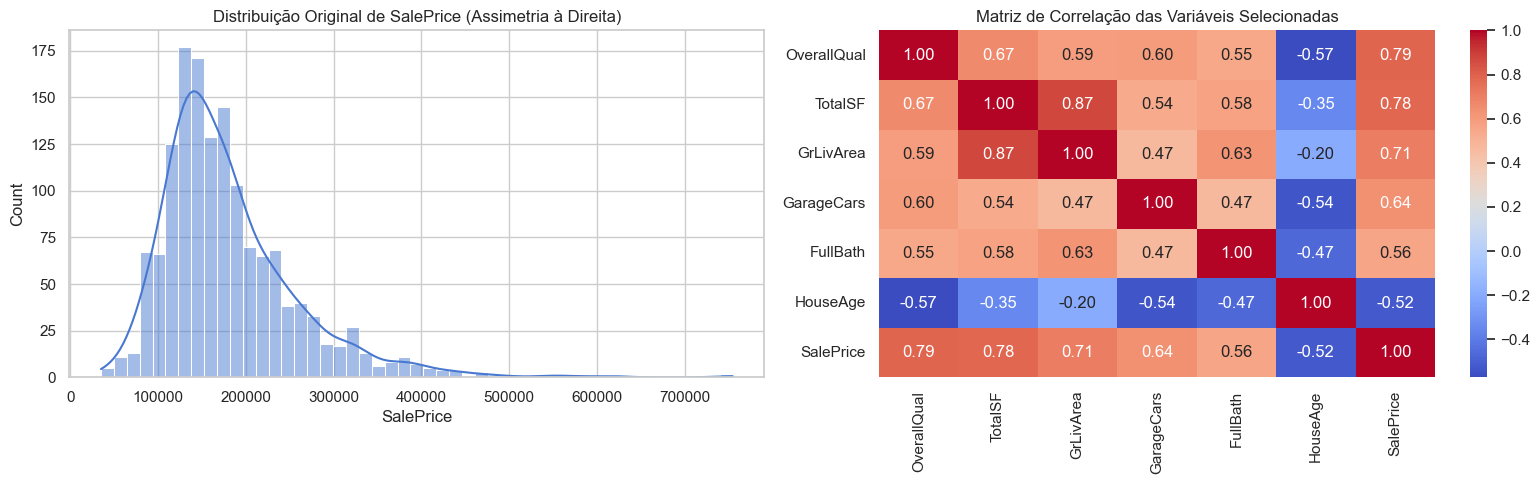

In [9]:
# --- VISUALIZAÇÃO 1: Distribuição dos Preços (Target) ---
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['SalePrice'], kde=True, ax=ax[0], color='b')
ax[0].set_title('Distribuição Original de SalePrice (Assimetria à Direita)')

# Tratamento de Missing Values de forma explícita
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Feature Engineering: Criação de novas variáveis explicativas
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF'] # Área total construída

# Seleção das características mais fortes para os modelos
features = ['OverallQual', 'TotalSF', 'GrLivArea', 'GarageCars', 'FullBath', 'HouseAge']
X = df[features]
y_reg = df['SalePrice']

# --- VISUALIZAÇÃO 2: Correlação das Features Selecionadas ---
sns.heatmap(df[features + ['SalePrice']].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=ax[1])
ax[1].set_title('Matriz de Correlação das Variáveis Selecionadas')
plt.tight_layout()
plt.show()

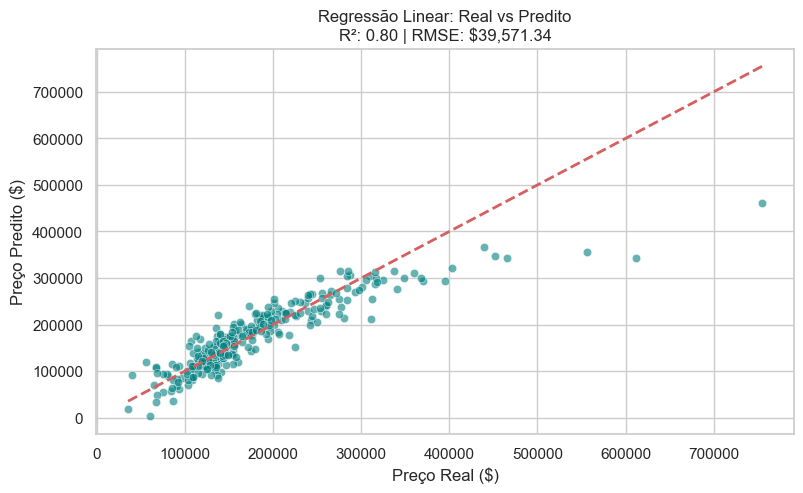

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred_reg = reg_model.predict(X_test)

# Métricas exigidas
rmse = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2 = r2_score(y_test, y_pred_reg)

# --- VISUALIZAÇÃO 3: Desempenho da Regressão ---
plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_test, y=y_pred_reg, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Regressão Linear: Real vs Predito\nR²: {r2:.2f} | RMSE: ${rmse:,.2f}')
plt.xlabel('Preço Real ($)')
plt.ylabel('Preço Predito ($)')
plt.show()

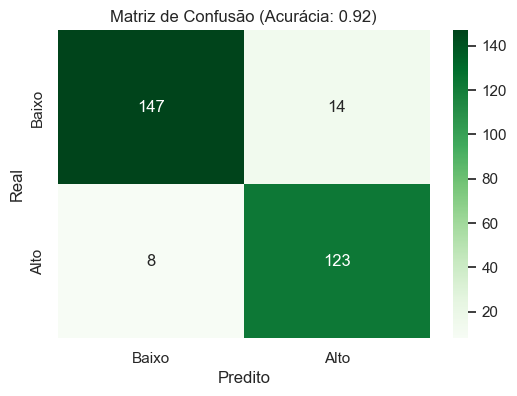


Relatório de Classificação Completo:
              precision    recall  f1-score   support

 Preço Baixo       0.95      0.91      0.93       161
  Preço Alto       0.90      0.94      0.92       131

    accuracy                           0.92       292
   macro avg       0.92      0.93      0.92       292
weighted avg       0.93      0.92      0.92       292



In [11]:
# Transformando a saída em variável binária pela mediana
mediana_preco = df['SalePrice'].median()
df['PriceCategory'] = np.where(df['SalePrice'] > mediana_preco, 1, 0) # 1: Alto, 0: Baixo

y_class = df['PriceCategory']
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

clf_model = RandomForestClassifier(random_state=42, n_estimators=100)
clf_model.fit(Xc_train, yc_train)
yc_pred = clf_model.predict(Xc_test)

# --- VISUALIZAÇÃO 4: Matriz de Confusão ---
cm = confusion_matrix(yc_test, yc_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Baixo', 'Alto'], yticklabels=['Baixo', 'Alto'])
plt.title(f'Matriz de Confusão (Acurácia: {accuracy_score(yc_test, yc_pred):.2f})')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

print("\nRelatório de Classificação Completo:")
print(classification_report(yc_test, yc_pred, target_names=['Preço Baixo', 'Preço Alto']))

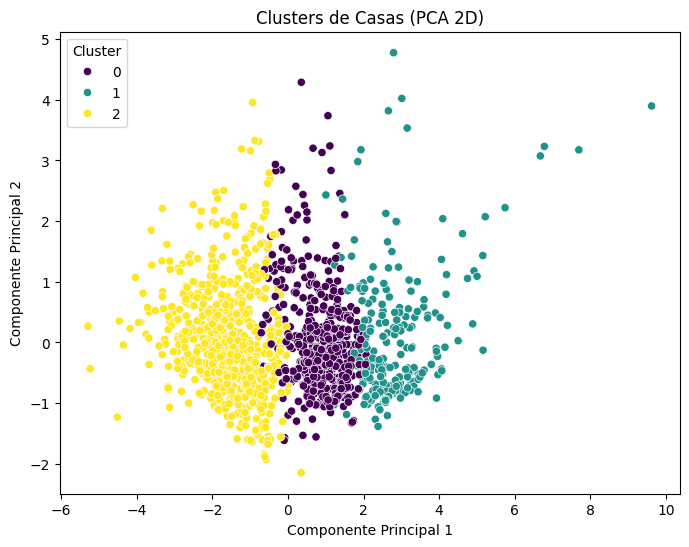

In [5]:
# Padronizando os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clusterização: Identificando grupos de casas semelhantes
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Redução de Dimensionalidade (PCA) para visualização em 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['Cluster'], palette='viridis')
plt.title('Clusters de Casas (PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

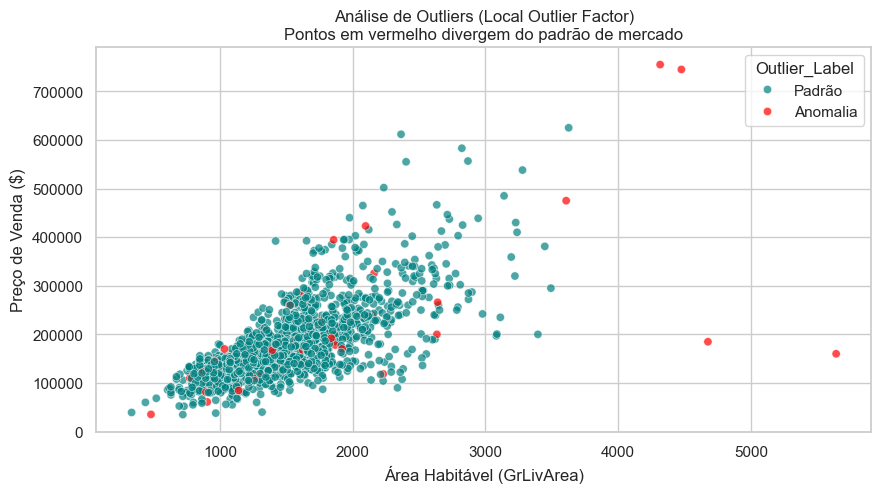


--- Regras de Associação Encontradas (Apriori) ---


,antecedents,consequents,support,confidence,lift
6,(Cozinha_Excelente),"(Garagem_Ampla, Ar_Condicionado)",0.062329,0.910000,1.355714
2,(Cozinha_Excelente),(Garagem_Ampla),0.063014,0.920000,1.329901
5,"(Ar_Condicionado, Cozinha_Excelente)",(Garagem_Ampla),0.062329,0.919192,1.328733
3,(Cozinha_Excelente),(Ar_Condicionado),0.067808,0.990000,1.058901
4,"(Garagem_Ampla, Cozinha_Excelente)",(Ar_Condicionado),0.062329,0.989130,1.057971


In [ ]:
# 1. Análise de Outliers com LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
df['Outlier'] = lof.fit_predict(X_scaled)

# Mapeando os números para texto para o Seaborn criar a legenda corretamente
df['Outlier_Label'] = df['Outlier'].map({1: 'Padrão', -1: 'Anomalia'})

# --- VISUALIZAÇÃO 6: Destacando Anomalias ---
plt.figure(figsize=(10, 5))

# Trocamos 'TotalSF' por 'GrLivArea' que é uma coluna nativa do dataset
sns.scatterplot(
    x=df['GrLivArea'], 
    y=df['SalePrice'], 
    hue=df['Outlier_Label'], 
    palette={'Padrão': 'teal', 'Anomalia': 'red'}, 
    alpha=0.7
)

plt.title('Análise de Outliers (Local Outlier Factor)\nPontos em vermelho divergem do padrão de mercado')
plt.xlabel('Área Habitável (GrLivArea)')
plt.ylabel('Preço de Venda ($)')
plt.show()

# 2. Análise de Associação 
df_assoc = pd.DataFrame({
    'Garagem_Ampla': df['GarageCars'] >= 2,
    'Ar_Condicionado': df['CentralAir'] == 'Y',
    'Cozinha_Excelente': df['KitchenQual'] == 'Ex'
})

frequent_itemsets = apriori(df_assoc, min_support=0.05, use_colnames=True)
regras = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5, num_itemsets=len(frequent_itemsets))

print("\n--- Regras de Associação Encontradas (Apriori) ---")
display(regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False).head())